In [1]:
!pip install qiskit qiskit-machine-learning torch scikit-learn matplotlib -q

In [2]:
import qiskit
import torch
import sklearn
import matplotlib

print( qiskit.__version__)
print( torch.__version__)


2.4.1
2.12.0+cpu


In [3]:
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt


Train samples: 320
Test samples: 80


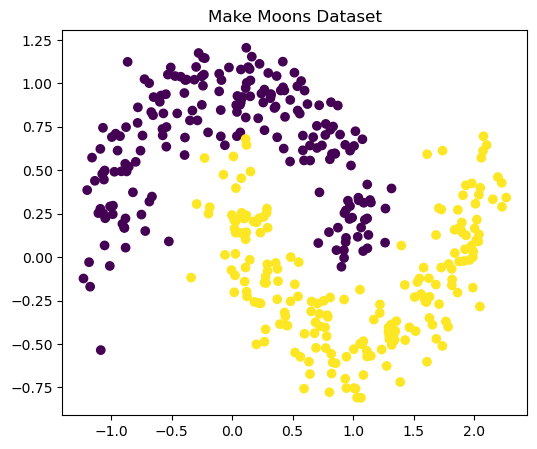

In [4]:

# Generate dataset
X, y = make_moons(
    n_samples=400,
    noise=0.15,
    random_state=42
)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Train samples:", len(X_train))
print("Test samples:", len(X_test))

# Visualize
plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], c=y)
plt.title("Make Moons Dataset")
plt.show()

In [5]:
import numpy as np

# indices of each class
class0_idx = np.where(y_train == 0)[0]
class1_idx = np.where(y_train == 1)[0]

# shuffle
np.random.shuffle(class0_idx)
np.random.shuffle(class1_idx)

# Client 1: 80% class 0, 20% class 1
client1_idx = np.concatenate([
    class0_idx[:128],
    class1_idx[:32]
])

# Client 2: 80% class 1, 20% class 0
client2_idx = np.concatenate([
    class1_idx[32:160],
    class0_idx[128:160]
])

X_client1 = X_train[client1_idx]
y_client1 = y_train[client1_idx]

X_client2 = X_train[client2_idx]
y_client2 = y_train[client2_idx]

print("Client 1 samples:", len(X_client1))
print("Client 2 samples:", len(X_client2))

print("\nClient 1 class distribution:")
print(np.bincount(y_client1))

print("\nClient 2 class distribution:")
print(np.bincount(y_client2))

Client 1 samples: 160
Client 2 samples: 158

Client 1 class distribution:
[128  32]

Client 2 class distribution:
[ 30 128]


In [6]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

scaler = MinMaxScaler(feature_range=(0, np.pi))

X_client1 = scaler.fit_transform(X_client1)
X_client2 = scaler.transform(X_client2)
X_test = scaler.transform(X_test)

print("Client 1 shape:", X_client1.shape)
print("Client 2 shape:", X_client2.shape)
print("Test shape:", X_test.shape)

print("\nExample sample:")
print(X_client1[0])

Client 1 shape: (160, 2)
Client 2 shape: (158, 2)
Test shape: (80, 2)

Example sample:
[0.16196573 1.95846421]


### ✓ Dataset
### ✓ Train/Test Split
### ✓ Non-IID Clients
### ✓ Feature Scaling

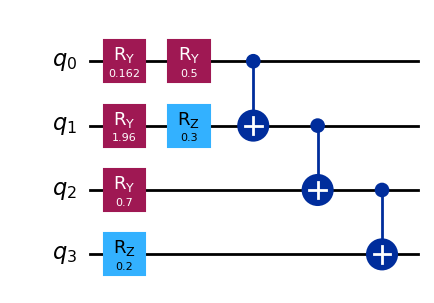

In [7]:
from qiskit import QuantumCircuit

n_qubits = 4

qc = QuantumCircuit(n_qubits)

# Example sample
x = X_client1[0]

# Angle Encoding
qc.ry(x[0], 0)
qc.ry(x[1], 1)

# Trainable Layer (dummy values for now)
qc.ry(0.5, 0)
qc.rz(0.3, 1)
qc.ry(0.7, 2)
qc.rz(0.2, 3)

# Entanglement
qc.cx(0, 1)
qc.cx(1, 2)
qc.cx(2, 3)

qc.draw('mpl')

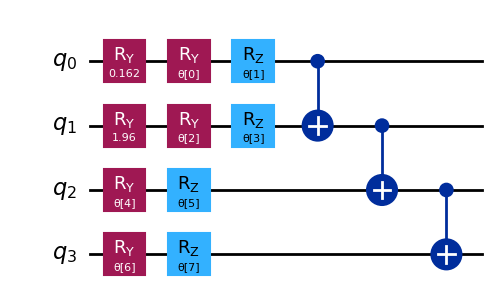

In [8]:
from qiskit.circuit import ParameterVector
from qiskit import QuantumCircuit

n_qubits = 4

# trainable parameters
theta = ParameterVector("θ", length=8)

qc = QuantumCircuit(n_qubits)

# data encoding
x = X_client1[0]

qc.ry(x[0], 0)
qc.ry(x[1], 1)

# variational layer
for i in range(n_qubits):
    qc.ry(theta[2*i], i)
    qc.rz(theta[2*i + 1], i)

# entanglement
for i in range(n_qubits - 1):
    qc.cx(i, i + 1)

qc.draw("mpl")

In [9]:
from qiskit.circuit import QuantumCircuit, ParameterVector
from qiskit.quantum_info import SparsePauliOp

n_qubits = 4

# Input parameters
x_params = ParameterVector("x", 2)

# Trainable parameters
theta = ParameterVector("θ", 8)

qc = QuantumCircuit(n_qubits)

# Data encoding
qc.ry(x_params[0], 0)
qc.ry(x_params[1], 1)

# Variational layer
for i in range(n_qubits):
    qc.ry(theta[2*i], i)
    qc.rz(theta[2*i + 1], i)

# Entanglement
for i in range(n_qubits - 1):
    qc.cx(i, i + 1)

# Observable
observable = SparsePauliOp.from_list([("ZZZZ", 1)])

print(qc)

     ┌──────────┐┌──────────┐┌──────────┐               
q_0: ┤ Ry(x[0]) ├┤ Ry(θ[0]) ├┤ Rz(θ[1]) ├──■────────────
     ├──────────┤├──────────┤├──────────┤┌─┴─┐          
q_1: ┤ Ry(x[1]) ├┤ Ry(θ[2]) ├┤ Rz(θ[3]) ├┤ X ├──■───────
     ├──────────┤├──────────┤└──────────┘└───┘┌─┴─┐     
q_2: ┤ Ry(θ[4]) ├┤ Rz(θ[5]) ├─────────────────┤ X ├──■──
     ├──────────┤├──────────┤                 └───┘┌─┴─┐
q_3: ┤ Ry(θ[6]) ├┤ Rz(θ[7]) ├──────────────────────┤ X ├
     └──────────┘└──────────┘                      └───┘


In [11]:
from qiskit_machine_learning.neural_networks import EstimatorQNN

qnn = EstimatorQNN(
    circuit=qc,
    input_params=x_params,
    weight_params=theta,
    observables=observable
)

print("QNN created successfully!")

No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


QNN created successfully!


In [13]:

# Random initial weights
weights = np.random.rand(8)

# First sample
sample = X_client1[0]

output = qnn.forward(
    input_data=sample,
    weights=weights
)

print("Input:", sample)
print("Output:", output)

Input: [0.16196573 1.95846421]
Output: [[-0.50911252]]


### The quantum circuit executed.

### The measurement executed.

### The observable executed.

### Everything is wired correctly.

# Convert QNN → Trainable Classifier

In [14]:
from qiskit_machine_learning.algorithms.classifiers import NeuralNetworkClassifier
from qiskit_machine_learning.utils.loss_functions import CrossEntropyLoss
from qiskit_algorithms.optimizers import COBYLA

classifier = NeuralNetworkClassifier(
    neural_network=qnn,
    optimizer=COBYLA(maxiter=50),
    loss=CrossEntropyLoss(),
    one_hot=False
)

print("Classifier created!")

Classifier created!


In [15]:
classifier.fit(X_client1, y_client1)


In [16]:
train_acc = classifier.score(X_client1, y_client1)
test_acc = classifier.score(X_test, y_test)

print(f"Train Accuracy: {train_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

Train Accuracy: 0.2000
Test Accuracy: 0.4750


In [17]:
preds = classifier.predict(X_client1[:20])

print("Predictions:")
print(preds)

print("\nActual:")
print(y_client1[:20])

Predictions:
[[ 1.]
 [ 1.]
 [ 1.]
 [ 1.]
 [-1.]
 [ 1.]
 [-1.]
 [-1.]
 [ 1.]
 [ 1.]
 [ 1.]
 [ 1.]
 [-1.]
 [ 1.]
 [ 1.]
 [ 1.]
 [ 1.]
 [ 1.]
 [-1.]
 [ 1.]]

Actual:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [18]:
print(np.unique(y_client1, return_counts=True))

(array([0, 1]), array([128,  32]))


In [19]:
print("Unique predictions:")
print(np.unique(classifier.predict(X_client1)))

Unique predictions:
[-1.  1.]


In [20]:
y_client1_q = 2 * y_client1 - 1
y_client2_q = 2 * y_client2 - 1
y_test_q = 2 * y_test - 1

print(np.unique(y_client1_q))
print(np.unique(y_test_q))

[-1  1]
[-1  1]


In [21]:
from qiskit_machine_learning.algorithms.classifiers import NeuralNetworkClassifier
from qiskit_machine_learning.utils.loss_functions import CrossEntropyLoss
from qiskit_algorithms.optimizers import COBYLA

classifier = NeuralNetworkClassifier(
    neural_network=qnn,
    optimizer=COBYLA(maxiter=100),
    loss=CrossEntropyLoss(),
    one_hot=False
)

In [22]:
classifier.fit(X_client1, y_client1_q)

In [23]:
train_acc = classifier.score(X_client1, y_client1_q)
test_acc = classifier.score(X_test, y_test_q)

print(f"Train Accuracy: {train_acc:.4f}")
print(f"Test Accuracy : {test_acc:.4f}")

Train Accuracy: 0.9187
Test Accuracy : 0.7375


### ✓ Quantum circuit works
### ✓ QNN works
### ✓ Training works
### ✓ Classification works
### ✓ Non-IID dataset works

In [24]:
from qiskit_machine_learning.algorithms.classifiers import NeuralNetworkClassifier
from qiskit_machine_learning.utils.loss_functions import CrossEntropyLoss
from qiskit_algorithms.optimizers import COBYLA

classifier_client2 = NeuralNetworkClassifier(
    neural_network=qnn,
    optimizer=COBYLA(maxiter=100),
    loss=CrossEntropyLoss(),
    one_hot=False
)

classifier_client2.fit(X_client2, y_client2_q)

print("Client 2 trained!")

Client 2 trained!


In [25]:
train_acc2 = classifier_client2.score(X_client2, y_client2_q)
test_acc2 = classifier_client2.score(X_test, y_test_q)

print(f"Client 2 Train Accuracy: {train_acc2:.4f}")
print(f"Client 2 Test Accuracy : {test_acc2:.4f}")

Client 2 Train Accuracy: 0.9177
Client 2 Test Accuracy : 0.7875


In [26]:
print(classifier.weights)

[1.36765211 0.83013565 0.2539151  0.49150359 0.36293059 0.19475784
 0.17854927 0.10473428]


In [27]:
print(classifier_client2.weights)

[ 3.03081649  0.01040235 -0.749692    1.9276714   1.59371063  0.1261074
 -0.21419882  0.78586758]


# We have 
Client 1
 ↓
Quantum Model
 ↓
θ₁

Client 2
 ↓
Quantum Model
 ↓
θ₂